# Multi-Model Comparison: SVM vs CA-BiLSTM vs TCN
## Marmoset Lick Classification — Cerebellar Purkinje Cell Recordings
**Data:** Hage et al., PLOS Biology 2025  
**Goal:** Rigorous multi-seed comparison (SVM / CA-BiLSTM / TCN) on balanced accuracy (BAC).  
**Primary test:** One-sided paired t-test + bootstrap CI on whether TCN ≥ CA-BiLSTM.


In [1]:
!pip install h5py -q

In [2]:
import os, time, random, warnings
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


## Constants & Seed Utility

In [3]:
LABEL_NAMES = [
    'groom',
    'inner_tube_success', 'inner_tube_fail',
    'outer_edge_success', 'outer_edge_fail',
    'under_tube_success', 'under_tube_fail',
]
SHORT_NAMES = [
    'groom', 'inner\nsuccess', 'inner\nfail',
    'outer\nsuccess', 'outer\nfail',
    'under\nsuccess', 'under\nfail',
]
N_CLASSES        = 7
POSITION_NAMES   = ['groom', 'inner_tube', 'outer_edge', 'under_tube']
N_POSITIONS      = 4
LABEL_TO_POSITION = np.array([0, 1, 1, 2, 2, 3, 3], dtype=np.int64)

WINDOW_PRE  = 0.20
WINDOW_POST = 0.40
BIN_SIZE    = 0.020
N_BINS      = int(round((WINDOW_PRE + WINDOW_POST) / BIN_SIZE))   # 30
print(f'N_BINS: {N_BINS}')

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


N_BINS: 30


## Config

In [4]:
# ── Kaggle-ready paths (TCN notebook convention) ──────────────────────────
KAGGLE_MATS = [
    '/kaggle/input/datasets/rahymfaisalkhan/dataset/1D_1.mat',
    '/kaggle/input/datasets/rahymfaisalkhan/dataset/1D_2.mat',
]
LOCAL_MATS  = ['1D_1.mat', '1D_2.mat']
MAT_PATHS   = LOCAL_MATS if all(os.path.exists(p) for p in LOCAL_MATS) else KAGGLE_MATS

# Seeds — every model is trained on IDENTICAL (seed, data-split) pairs
SEEDS = [42, 7, 123, 2024, 999]   # 5 independent runs

CONFIG = {
    # ── data ──────────────────────────────────────────
    'val_size':             0.15,
    'test_size':            0.15,
    # ── shared training ────────────────────────────────
    'batch_size':           64,
    'epochs':               80,
    'grad_clip':            1.0,
    'use_class_weights':    True,
    'use_weighted_sampler': True,
    # ── CA-BiLSTM ──────────────────────────────────────
    'lstm_hidden':          128,
    'lstm_layers':          2,
    'lstm_dropout':         0.3,
    'lstm_ca_reduction':    2,
    'lstm_lr':              3e-4,
    'lstm_wd':              1e-4,
    # ── TCN ────────────────────────────────────────────
    'tcn_channels':         (64, 64, 96, 96),
    'tcn_k':                3,
    'tcn_drop':             0.2,
    'tcn_type_embed':       8,
    'tcn_cond_dim':         16,
    'tcn_local_k':          5,
    'tcn_lr':               8e-4,
    'tcn_wd':               2e-4,
    'tcn_aux_pos_weight':   0.4,
    # ── output ─────────────────────────────────────────
    'save_dir':             '/kaggle/working/checkpoints',
}
os.makedirs(CONFIG['save_dir'], exist_ok=True)
print('MAT_PATHS:', MAT_PATHS)


MAT_PATHS: ['/kaggle/input/datasets/rahymfaisalkhan/dataset/1D_1.mat', '/kaggle/input/datasets/rahymfaisalkhan/dataset/1D_2.mat']


## Data Loading
Shared pipeline: `.mat` → `(N, T=30, C=9)` tensor.
TCN also receives a 10th channel (soft CS-fraction signal). LSTM uses only the first 9.

In [5]:
def _spike_psth(spike_times, lick_onsets):
    bins = np.linspace(-WINDOW_PRE, WINDOW_POST, N_BINS + 1)
    psth = np.zeros((len(lick_onsets), N_BINS), dtype=np.float32)
    for i, onset in enumerate(lick_onsets):
        t_rel = spike_times - onset
        mask  = (t_rel >= -WINDOW_PRE) & (t_rel <= WINDOW_POST)
        psth[i], _ = np.histogram(t_rel[mask], bins=bins)
    return psth


def _find_spike_pair(refs, lick_key):
    onsets = refs[f'{lick_key}/time_onset'][()].flatten()
    lick_start, lick_end = onsets[0], onsets[-1]
    all_keys = [
        k for k in refs
        if hasattr(refs[k], 'keys') and 'SS_time' in refs[k] and 'CS_time' in refs[k]
    ]
    scored = []
    for k in all_keys:
        ss = refs[f'{k}/SS_time'][()].flatten()
        scored.append((k, int(((ss >= lick_start) & (ss <= lick_end)).sum()), ss[0]))
    scored.sort(key=lambda t: -t[1])

    if scored[0][1] == 0:          # fallback: offset alignment
        ref_start = scored[0][2]
        rescored = []
        for k, _, ss0 in scored:
            ss  = refs[f'{k}/SS_time'][()].flatten()
            off = ref_start - ss0
            ov  = int((((ss+off) >= lick_start) & ((ss+off) <= lick_end)).sum())
            rescored.append((k, off, ov))
        rescored.sort(key=lambda t: -t[2])
        k1, o1 = rescored[0][0], rescored[0][1]
        k2 = rescored[1][0] if len(rescored) > 1 else k1
        o2 = rescored[1][1] if len(rescored) > 1 else o1
        return k1, o1, k2, o2

    k1, o1    = scored[0][0], 0.0
    abs_start = refs[f'{k1}/SS_time'][()].flatten()[0]
    remaining = scored[1:]
    if remaining:
        rel = []
        for k, dov, ss0 in remaining:
            if dov > 0:
                rel.append((k, 0.0, dov))
            else:
                ss  = refs[f'{k}/SS_time'][()].flatten()
                off = abs_start - ss0
                ov  = int((((ss+off) >= lick_start) & ((ss+off) <= lick_end)).sum())
                rel.append((k, off, ov))
        rel.sort(key=lambda t: -t[2])
        k2, o2 = rel[0][0], rel[0][1]
    else:
        k2, o2 = k1, 0.0
    return k1, o1, k2, o2


def _load_session(f, lick_key):
    refs     = f['#refs#']
    lick_grp = refs[lick_key]
    y        = lick_grp['tag_lick'][()].flatten().astype(int) - 1
    onsets   = lick_grp['time_onset'][()].flatten()
    k1, o1, k2, o2 = _find_spike_pair(refs, lick_key)
    ss1 = refs[f'{k1}/SS_time'][()].flatten() + o1
    cs1 = refs[f'{k1}/CS_time'][()].flatten() + o1
    ss2 = refs[f'{k2}/SS_time'][()].flatten() + o2
    cs2 = refs[f'{k2}/CS_time'][()].flatten() + o2
    X_seq = np.stack([
        _spike_psth(ss1, onsets), _spike_psth(ss2, onsets),
        _spike_psth(cs1, onsets), _spike_psth(cs2, onsets),
    ], axis=-1)
    kin_keys = ['duration_lick', 'tongue_vm_max', 'tongue_vm_min',
                'tongue_dm_max', 'tongue_ang_max']
    X_kin = np.column_stack(
        [lick_grp[k][()].flatten() for k in kin_keys]).astype(np.float32)
    return X_seq, X_kin, y


def load_mat_file(path):
    Xs, Xk, Ys = [], [], []
    with h5py.File(path, 'r') as f:
        refs = f['#refs#']
        lick_keys = sorted(
            [k for k in refs if hasattr(refs[k], 'keys') and 'tag_lick' in refs[k]],
            key=lambda k: float(refs[f'{k}/time_onset'][()].flatten()[0]),
        )
        print(f'  {len(lick_keys)} session(s) in {os.path.basename(path)}')
        for lk in lick_keys:
            xs, xk, yy = _load_session(f, lk)
            Xs.append(xs); Xk.append(xk); Ys.append(yy)
    return np.concatenate(Xs), np.concatenate(Xk), np.concatenate(Ys)


def build_arrays(mat_paths, seed=42):
    """
    Returns:
      X9   (N,T, 9)  — 4 spike + 5 kin, normalised  [LSTM & SVM]
      X10  (N,T,10)  — X9 + CS-fraction channel      [TCN]
      y    (N,)      — 7-class labels (0-indexed)
      idx_train / idx_val / idx_test
      class_weights (torch.Tensor, 7)
      pos_class_weights (torch.Tensor, 4)
    """
    seqs, kins, ys = [], [], []
    print('Loading data …')
    for p in mat_paths:
        xs, xk, yy = load_mat_file(p)
        seqs.append(xs); kins.append(xk); ys.append(yy)
    X_seq_raw = np.concatenate(seqs)
    X_kin_raw = np.concatenate(kins)
    y         = np.concatenate(ys)

    idx = np.arange(len(y))
    idx_tv, idx_test = train_test_split(
        idx, test_size=CONFIG['test_size'], stratify=y, random_state=seed)
    idx_train, idx_val = train_test_split(
        idx_tv, test_size=CONFIG['val_size'] / (1 - CONFIG['test_size']),
        stratify=y[idx_tv], random_state=seed)

    N, T, C = X_seq_raw.shape
    sc_seq  = StandardScaler().fit(X_seq_raw[idx_train].reshape(-1, C))
    sc_kin  = StandardScaler().fit(X_kin_raw[idx_train])
    X_seq_n = sc_seq.transform(X_seq_raw.reshape(-1, C)).reshape(N, T, C)
    X_kin_n = sc_kin.transform(X_kin_raw)
    X_kin_r = np.repeat(X_kin_n[:, np.newaxis, :], T, axis=1)

    # Soft CS-fraction channel (TCN type gate)
    ss_c    = X_seq_raw[..., 0] + X_seq_raw[..., 1]
    cs_c    = X_seq_raw[..., 2] + X_seq_raw[..., 3]
    cs_frac = (cs_c / (ss_c + cs_c + 1e-8)).astype(np.float32)[..., np.newaxis]

    X9  = np.concatenate([X_seq_n, X_kin_r],           axis=-1).astype(np.float32)
    X10 = np.concatenate([X_seq_n, X_kin_r, cs_frac],  axis=-1).astype(np.float32)

    cc  = np.bincount(y, minlength=N_CLASSES).astype(float)
    cw  = torch.tensor(1.0 / np.where(cc>0, cc, 1.0), dtype=torch.float32)
    cw /= cw.sum()

    y_pos = LABEL_TO_POSITION[y]
    pc    = np.bincount(y_pos[idx_train], minlength=N_POSITIONS).astype(float)
    pcw   = torch.tensor(1.0 / np.where(pc>0, pc, 1.0), dtype=torch.float32)
    pcw  /= pcw.sum()

    print(f'  Total: {len(y)} licks  '
          f'| train={len(idx_train)}, val={len(idx_val)}, test={len(idx_test)}')
    return X9, X10, y, idx_train, idx_val, idx_test, cw, pcw


# Quick sanity check
print('\nSanity-check load (seed=42):')
_X9, _X10, _y, *_ = build_arrays(MAT_PATHS, seed=42)
print(f'X9={_X9.shape}  X10={_X10.shape}')
unique, counts = np.unique(_y, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  [{u}] {LABEL_NAMES[u]}: {c}')
del _X9, _X10, _y



Sanity-check load (seed=42):
Loading data …
  3 session(s) in 1D_1.mat
  5 session(s) in 1D_2.mat
  Total: 14002 licks  | train=9800, val=2101, test=2101
X9=(14002, 30, 9)  X10=(14002, 30, 10)
  [0] groom: 2522
  [1] inner_tube_success: 652
  [2] inner_tube_fail: 353
  [3] outer_edge_success: 52
  [4] outer_edge_fail: 2396
  [5] under_tube_success: 1783
  [6] under_tube_fail: 6244


## Dataset & DataLoader Helpers

In [6]:
class LickDataset9(Dataset):
    """CA-BiLSTM / SVM: (x9, label7)"""    
    def __init__(self, X9, y):
        self.X = torch.from_numpy(X9)
        self.y = torch.from_numpy(y.astype(np.int64))
    def __len__(self): 
        return len(self.y)
    def __getitem__(self, i): 
        return self.X[i], self.y[i]


class LickDataset10(Dataset):
    """TCN: (x10_transposed to C×T, label7, label_pos)"""    
    def __init__(self, X10, y, y_pos):
        self.X     = torch.from_numpy(X10)
        self.y7    = torch.from_numpy(y.astype(np.int64))
        self.y_pos = torch.from_numpy(y_pos.astype(np.int64))
    def __len__(self): return len(self.y7)
    def __getitem__(self, i):
        return self.X[i].transpose(0, 1), self.y7[i], self.y_pos[i]


def _weighted_sampler(labels):
    cnt = np.bincount(labels, minlength=N_CLASSES)
    wts = torch.from_numpy((1.0 / cnt[labels]).astype(np.float32))
    return WeightedRandomSampler(wts, len(wts), replacement=True)


def make_loaders_lstm(X9, y, idx_train, idx_val, idx_test):
    tr_ds = LickDataset9(X9[idx_train], y[idx_train])
    va_ds = LickDataset9(X9[idx_val],   y[idx_val])
    te_ds = LickDataset9(X9[idx_test],  y[idx_test])
    sampler = _weighted_sampler(y[idx_train]) if CONFIG['use_weighted_sampler'] else None
    tr_ld = DataLoader(tr_ds, batch_size=CONFIG['batch_size'],
                       sampler=sampler, shuffle=(sampler is None))
    return tr_ld, DataLoader(va_ds, CONFIG['batch_size']), DataLoader(te_ds, CONFIG['batch_size'])


def make_loaders_tcn(X10, y, idx_train, idx_val, idx_test):
    y_pos = LABEL_TO_POSITION[y]
    tr_ds = LickDataset10(X10[idx_train], y[idx_train], y_pos[idx_train])
    va_ds = LickDataset10(X10[idx_val],   y[idx_val],   y_pos[idx_val])
    te_ds = LickDataset10(X10[idx_test],  y[idx_test],  y_pos[idx_test])
    sampler = _weighted_sampler(y[idx_train]) if CONFIG['use_weighted_sampler'] else None
    tr_ld = DataLoader(tr_ds, batch_size=CONFIG['batch_size'],
                       sampler=sampler, shuffle=(sampler is None))
    return tr_ld, DataLoader(va_ds, CONFIG['batch_size']), DataLoader(te_ds, CONFIG['batch_size'])


## Model Definitions

In [7]:
# ═══════════════════════════════════════════════════
# 1. CA-BiLSTM
# ═══════════════════════════════════════════════════
class ChannelAttention(nn.Module):
    def __init__(self, n_ch, reduction=2):
        super().__init__()
        b = max(1, n_ch // reduction)
        self.fc = nn.Sequential(
            nn.Linear(n_ch, b, bias=False), nn.ReLU(inplace=True),
            nn.Linear(b, n_ch, bias=False), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x.mean(dim=1)).unsqueeze(1)

class TemporalAttention(nn.Module):
    def __init__(self, h):
        super().__init__()
        self.attn = nn.Linear(h, 1)
    def forward(self, h):
        w = F.softmax(self.attn(torch.tanh(h)), dim=1)
        return (w * h).sum(dim=1), w.squeeze(-1)

class CABiLSTM(nn.Module):
    def __init__(self, input_size=9, hidden_size=128, n_layers=2,
                 n_classes=7, dropout=0.3, ca_reduction=2):
        super().__init__()
        self.ch_attn = ChannelAttention(input_size, ca_reduction)
        self.bilstm  = nn.LSTM(input_size, hidden_size, n_layers,
                               batch_first=True, bidirectional=True,
                               dropout=dropout if n_layers>1 else 0.0)
        self.t_attn  = TemporalAttention(hidden_size * 2)
        self.drop    = nn.Dropout(dropout)
        self.clf     = nn.Linear(hidden_size * 2, n_classes)
        for name, p in self.bilstm.named_parameters():
            if   'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'bias'      in name: nn.init.zeros_(p)
        nn.init.xavier_uniform_(self.clf.weight); nn.init.zeros_(self.clf.bias)

    def forward(self, x, return_attention=False):
        x = self.ch_attn(x)
        h, _ = self.bilstm(x)
        ctx, wts = self.t_attn(h)
        logits = self.clf(self.drop(ctx))
        return (logits, wts) if return_attention else logits


# ═══════════════════════════════════════════════════
# 2. TCN
# ═══════════════════════════════════════════════════
class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, d=1, p_drop=0.2, teb=8):
        super().__init__()
        pad = (k-1)*d
        self.te    = nn.Sequential(nn.Conv1d(1,teb,1), nn.GELU(), nn.Conv1d(teb,in_ch,1))
        self.c1    = nn.Conv1d(in_ch, out_ch, k, dilation=d, padding=pad)
        self.c2    = nn.Conv1d(out_ch, out_ch, k, dilation=d, padding=pad)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(p_drop)
        self.down  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.k = k; self.d = d
    def _chomp(self, x):
        cut = (self.k-1)*self.d
        return x[:,:,:-cut] if cut>0 else x
    def forward(self, x, tg):
        xc = x + self.te(tg)
        y  = self.drop(F.gelu(self.bn1(self._chomp(self.c1(xc)))))
        y  = self.drop(F.gelu(self.bn2(self._chomp(self.c2(y)))))
        return y + self.down(x)

class TCNClassifier(nn.Module):
    def __init__(self, in_ch=10, channels=(64,64,96,96), k=3, p_drop=0.2,
                 teb=8, cond_dim=16, n_classes=7, local_k=5):
        super().__init__()
        self.feat_ch = in_ch - 1
        self.lk      = local_k
        layers, c = [], self.feat_ch
        for i, oc in enumerate(channels):
            layers.append(TemporalBlock(c, oc, k, 2**i, p_drop, teb)); c = oc
        self.tcn  = nn.ModuleList(layers)
        fd        = 2 * c
        self.pos_head = nn.Sequential(nn.Linear(fd,96), nn.GELU(), nn.Dropout(0.3), nn.Linear(96,N_POSITIONS))
        self.pos_emb  = nn.Embedding(N_POSITIONS, cond_dim)
        self.main_head = nn.Sequential(nn.Linear(fd+cond_dim,128), nn.GELU(), nn.Dropout(0.35), nn.Linear(128,n_classes))

    def forward(self, x):
        h  = x[:, :self.feat_ch, :]
        tg = x[:, self.feat_ch:self.feat_ch+1, :].clamp(0,1)
        for blk in self.tcn: h = blk(h, tg)
        gm   = h.mean(-1)
        lm   = h[:,:,-self.lk:].mean(-1)
        fus  = torch.cat([gm, lm], 1)
        plg  = self.pos_head(fus)
        pp   = torch.softmax(plg, -1)
        cond = pp @ self.pos_emb.weight
        lg7  = self.main_head(torch.cat([fus, cond], 1))
        return lg7, plg, pp


# ── Parameter counts (fixed across seeds) ──────────────────────
_lt = CABiLSTM(9, CONFIG['lstm_hidden'], CONFIG['lstm_layers'],
               dropout=CONFIG['lstm_dropout'], ca_reduction=CONFIG['lstm_ca_reduction'])
_tt = TCNClassifier(10, CONFIG['tcn_channels'], CONFIG['tcn_k'],
                    CONFIG['tcn_drop'], CONFIG['tcn_type_embed'],
                    CONFIG['tcn_cond_dim'], local_k=CONFIG['tcn_local_k'])
LSTM_PARAMS = sum(p.numel() for p in _lt.parameters() if p.requires_grad)
TCN_PARAMS  = sum(p.numel() for p in _tt.parameters()  if p.requires_grad)
del _lt, _tt
print(f'CA-BiLSTM params : {LSTM_PARAMS:,}')
print(f'TCN       params : {TCN_PARAMS:,}')


CA-BiLSTM params : 539,728
TCN       params : 197,564


## Per-Seed Training Functions

In [8]:
# ═══════════════════════════════════════════════════
# SVM (one seed)
# ═══════════════════════════════════════════════════
def train_svm(seed, X9, y, idx_train, idx_test):
    set_seed(seed)
    Xtr = X9[idx_train].reshape(len(idx_train), -1)
    Xte = X9[idx_test ].reshape(len(idx_test),  -1)
    ytr = y[idx_train]; yte = y[idx_test]

    t0  = time.time()
    svm = SVC(kernel='rbf', C=10, gamma='scale',
              class_weight='balanced', random_state=seed)
    svm.fit(Xtr, ytr)
    train_time = time.time() - t0

    # Single-sample latency
    t_i = time.time()
    for _ in range(100): svm.predict(Xte[:1])
    inf_ms = (time.time() - t_i) / 100 * 1000

    preds  = svm.predict(Xte)
    return {
        'test_bac':    balanced_accuracy_score(yte, preds),
        'test_acc':    (preds == yte).mean(),
        'test_preds':  preds,
        'test_labels': yte,
        'train_time':  train_time,
        'inf_ms':      inf_ms,
        'n_svs':       svm.n_support_.sum(),
    }


# ═══════════════════════════════════════════════════
# CA-BiLSTM (one seed)
# ═══════════════════════════════════════════════════
@torch.no_grad()
def _eval_lstm(model, loader, criterion):
    model.eval()
    tot_loss = correct = total = 0
    preds_all, labels_all = [], []
    for x, y in loader:
        x, y   = x.to(device), y.to(device)
        logits  = model(x)
        tot_loss += criterion(logits, y).item() * len(y)
        p = logits.argmax(1)
        correct += (p == y).sum().item(); total += len(y)
        preds_all.extend(p.cpu().numpy()); labels_all.extend(y.cpu().numpy())
    bac = balanced_accuracy_score(labels_all, preds_all)
    return tot_loss/total, correct/total, bac, np.array(preds_all), np.array(labels_all)


def train_lstm(seed, X9, y, idx_train, idx_val, idx_test, cw):
    set_seed(seed)
    tr_ld, va_ld, te_ld = make_loaders_lstm(X9, y, idx_train, idx_val, idx_test)

    model = CABiLSTM(9, CONFIG['lstm_hidden'], CONFIG['lstm_layers'],
                     N_CLASSES, CONFIG['lstm_dropout'],
                     CONFIG['lstm_ca_reduction']).to(device)
    crit  = nn.CrossEntropyLoss(
        weight=cw.to(device) if CONFIG['use_class_weights'] else None,
        label_smoothing=0.05)
    opt   = AdamW(model.parameters(), lr=CONFIG['lstm_lr'], weight_decay=CONFIG['lstm_wd'])
    sched = CosineAnnealingLR(opt, CONFIG['epochs'], eta_min=1e-6)

    best_bac, best_ep, best_state = -1., 0, None
    val_hist = []
    t0 = time.time()
    for ep in range(1, CONFIG['epochs']+1):
        model.train()
        for x, yb in tr_ld:
            x, yb = x.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(x), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            opt.step()
        sched.step()
        _, _, va_bac, _, _ = _eval_lstm(model, va_ld, crit)
        val_hist.append(va_bac)
        if va_bac > best_bac:
            best_bac = va_bac; best_ep = ep
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
    train_time = time.time() - t0

    model.load_state_dict(best_state)
    _, te_acc, te_bac, te_preds, te_labels = _eval_lstm(model, te_ld, crit)

    dummy = torch.randn(1, N_BINS, 9).to(device)
    model.eval()
    with torch.no_grad():
        t_i = time.time()
        for _ in range(100): model(dummy)
        inf_ms = (time.time()-t_i)/100*1000

    return {
        'test_bac':     te_bac,
        'test_acc':     te_acc,
        'test_preds':   te_preds,
        'test_labels':  te_labels,
        'best_epoch':   best_ep,
        'train_time':   train_time,
        'inf_ms':       inf_ms,
        'val_bac_hist': val_hist,
    }


# ═══════════════════════════════════════════════════
# TCN (one seed)
# ═══════════════════════════════════════════════════
def train_tcn(seed, X10, y, idx_train, idx_val, idx_test, cw, pcw):
    set_seed(seed)
    tr_ld, va_ld, te_ld = make_loaders_tcn(X10, y, idx_train, idx_val, idx_test)

    model  = TCNClassifier(10, CONFIG['tcn_channels'], CONFIG['tcn_k'],
                           CONFIG['tcn_drop'], CONFIG['tcn_type_embed'],
                           CONFIG['tcn_cond_dim'], N_CLASSES,
                           CONFIG['tcn_local_k']).to(device)
    c7     = nn.CrossEntropyLoss(weight=cw.to(device)  if CONFIG['use_class_weights'] else None)
    c_pos  = nn.CrossEntropyLoss(weight=pcw.to(device) if CONFIG['use_class_weights'] else None)
    opt    = AdamW(model.parameters(), lr=CONFIG['tcn_lr'], weight_decay=CONFIG['tcn_wd'])
    sched  = CosineAnnealingLR(opt, CONFIG['epochs'], eta_min=1e-5)

    best_bac, best_ep, best_state = -1., 0, None
    val_hist = []
    t0 = time.time()
    for ep in range(1, CONFIG['epochs']+1):
        model.train()
        for xb, y7b, ypos in tr_ld:
            xb, y7b, ypos = xb.to(device), y7b.to(device), ypos.to(device)
            lg7, lgp, _   = model(xb)
            loss = c7(lg7, y7b) + CONFIG['tcn_aux_pos_weight'] * c_pos(lgp, ypos)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            opt.step()
        sched.step()
        model.eval()
        p_all, l_all = [], []
        with torch.no_grad():
            for xb, y7b, _ in va_ld:
                p_all.extend(model(xb.to(device))[0].argmax(1).cpu().numpy())
                l_all.extend(y7b.numpy())
        va_bac = balanced_accuracy_score(l_all, p_all)
        val_hist.append(va_bac)
        if va_bac > best_bac:
            best_bac = va_bac; best_ep = ep
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
    train_time = time.time() - t0

    model.load_state_dict(best_state)
    model.eval()
    p_all, l_all = [], []
    with torch.no_grad():
        for xb, y7b, _ in te_ld:
            p_all.extend(model(xb.to(device))[0].argmax(1).cpu().numpy())
            l_all.extend(y7b.numpy())
    te_bac = balanced_accuracy_score(l_all, p_all)
    te_acc = (np.array(p_all)==np.array(l_all)).mean()

    dummy = torch.randn(1, 10, N_BINS).to(device)
    with torch.no_grad():
        t_i = time.time()
        for _ in range(100): model(dummy)
        inf_ms = (time.time()-t_i)/100*1000

    return {
        'test_bac':     te_bac,
        'test_acc':     te_acc,
        'test_preds':   np.array(p_all),
        'test_labels':  np.array(l_all),
        'best_epoch':   best_ep,
        'train_time':   train_time,
        'inf_ms':       inf_ms,
        'val_bac_hist': val_hist,
    }


## Multi-Seed Experiment Loop
All three models are trained on **identical** `(seed, data-split)` pairs so every comparison is paired.

In [9]:
results = {'svm': [], 'lstm': [], 'tcn': []}

for run_idx, seed in enumerate(SEEDS):
    print(f'\n{"="*62}')
    print(f'  RUN {run_idx+1}/{len(SEEDS)}   seed={seed}')
    print(f'{"="*62}')

    # Shared data — same split for all three models
    X9, X10, y, idx_train, idx_val, idx_test, cw, pcw = build_arrays(MAT_PATHS, seed=seed)

    # ── SVM ──────────────────────────────────────────────────────
    print('  [1/3] SVM …')
    r = train_svm(seed, X9, y, idx_train, idx_test)
    results['svm'].append(r)
    print(f'        BAC={r["test_bac"]:.4f}  time={r["train_time"]:.1f}s  SVs={r["n_svs"]}')

    # ── CA-BiLSTM ────────────────────────────────────────────────
    print('  [2/3] CA-BiLSTM …')
    r = train_lstm(seed, X9, y, idx_train, idx_val, idx_test, cw)
    results['lstm'].append(r)
    print(f'        BAC={r["test_bac"]:.4f}  best_ep={r["best_epoch"]}  time={r["train_time"]/60:.1f}min')

    # ── TCN ──────────────────────────────────────────────────────
    print('  [3/3] TCN …')
    r = train_tcn(seed, X10, y, idx_train, idx_val, idx_test, cw, pcw)
    results['tcn'].append(r)
    print(f'        BAC={r["test_bac"]:.4f}  best_ep={r["best_epoch"]}  time={r["train_time"]/60:.1f}min')

np.save(os.path.join(CONFIG['save_dir'], 'multi_seed_results.npy'), results, allow_pickle=True)
print('\nAll runs complete.')



  RUN 1/5   seed=42
Loading data …
  3 session(s) in 1D_1.mat
  5 session(s) in 1D_2.mat
  Total: 14002 licks  | train=9800, val=2101, test=2101
  [1/3] SVM …
        BAC=0.6266  time=11.0s  SVs=6956
  [2/3] CA-BiLSTM …
        BAC=0.7399  best_ep=15  time=1.6min
  [3/3] TCN …
        BAC=0.7043  best_ep=3  time=2.7min

  RUN 2/5   seed=7
Loading data …
  3 session(s) in 1D_1.mat
  5 session(s) in 1D_2.mat
  Total: 14002 licks  | train=9800, val=2101, test=2101
  [1/3] SVM …
        BAC=0.6047  time=11.1s  SVs=6905
  [2/3] CA-BiLSTM …
        BAC=0.7553  best_ep=23  time=1.8min
  [3/3] TCN …
        BAC=0.7060  best_ep=8  time=2.7min

  RUN 3/5   seed=123
Loading data …
  3 session(s) in 1D_1.mat
  5 session(s) in 1D_2.mat
  Total: 14002 licks  | train=9800, val=2101, test=2101
  [1/3] SVM …
        BAC=0.5857  time=10.1s  SVs=6900
  [2/3] CA-BiLSTM …
        BAC=0.7210  best_ep=28  time=1.8min
  [3/3] TCN …
        BAC=0.7096  best_ep=9  time=2.7min

  RUN 4/5   seed=2024
Loading dat

## Summary Statistics

In [10]:
svm_bacs   = np.array([r['test_bac'] for r in results['svm']])
lstm_bacs  = np.array([r['test_bac'] for r in results['lstm']])
tcn_bacs   = np.array([r['test_bac'] for r in results['tcn']])

svm_times  = np.array([r['train_time'] for r in results['svm']])
lstm_times = np.array([r['train_time'] for r in results['lstm']])
tcn_times  = np.array([r['train_time'] for r in results['tcn']])

svm_inf    = np.array([r['inf_ms'] for r in results['svm']])
lstm_inf   = np.array([r['inf_ms'] for r in results['lstm']])
tcn_inf    = np.array([r['inf_ms'] for r in results['tcn']])

lstm_best_eps = np.array([r['best_epoch'] for r in results['lstm']])
tcn_best_eps  = np.array([r['best_epoch'] for r in results['tcn']])

hdr = f"{'Model':<14}{'BAC mean':>10}{'BAC std':>9}{'BAC min':>9}{'BAC max':>9}{'Train(s)':>10}{'Inf(ms)':>9}"
sep = '─' * len(hdr)
print(sep); print(hdr); print(sep)
for nm, bacs, times, infs in [
    ('SVM',       svm_bacs,  svm_times,  svm_inf),
    ('CA-BiLSTM', lstm_bacs, lstm_times, lstm_inf),
    ('TCN',       tcn_bacs,  tcn_times,  tcn_inf),
]:
    print(f'{nm:<14}{bacs.mean():>10.4f}{bacs.std():>9.4f}{bacs.min():>9.4f}'
          f'{bacs.max():>9.4f}{times.mean():>10.1f}{infs.mean():>9.3f}')
print(sep)
print(f'\nBest epoch  CA-BiLSTM: {lstm_best_eps.mean():.1f} ± {lstm_best_eps.std():.1f}')
print(f'Best epoch  TCN      : {tcn_best_eps.mean():.1f}  ± {tcn_best_eps.std():.1f}')
print(f'\nTrainable parameters:')
print(f'  SVM       : N/A (kernel machine — support vector count varies)')
print(f'  CA-BiLSTM : {LSTM_PARAMS:,}')
print(f'  TCN       : {TCN_PARAMS:,}  ({TCN_PARAMS/LSTM_PARAMS:.2f}x LSTM)')


──────────────────────────────────────────────────────────────────────
Model           BAC mean  BAC std  BAC min  BAC max  Train(s)  Inf(ms)
──────────────────────────────────────────────────────────────────────
SVM               0.6113   0.0172   0.5857   0.6338      10.6    2.697
CA-BiLSTM         0.7200   0.0260   0.6835   0.7553     104.6    0.689
TCN               0.6982   0.0122   0.6757   0.7096     162.3    2.976
──────────────────────────────────────────────────────────────────────

Best epoch  CA-BiLSTM: 26.8 ± 15.1
Best epoch  TCN      : 9.0  ± 5.4

Trainable parameters:
  SVM       : N/A (kernel machine — support vector count varies)
  CA-BiLSTM : 539,728
  TCN       : 197,564  (0.37x LSTM)


## Statistical Tests

**Primary question:** Is TCN ≥ CA-BiLSTM in test BAC?

1. **Paired one-sided t-test** — H₀: μ(TCN−LSTM)=0 vs H₁: μ>0  
2. **Wilcoxon signed-rank test** (non-parametric alternative)  
3. **Bootstrap 95% CI** on mean(TCN BAC − LSTM BAC)


In [11]:
diff = tcn_bacs - lstm_bacs    # paired differences (same seeds/splits)

# ── 1. Paired one-sided t-test ───────────────────────────────────────────
t_stat, p_two = stats.ttest_rel(tcn_bacs, lstm_bacs)
p_one = p_two/2 if t_stat >= 0 else 1 - p_two/2

print('── Paired one-sided t-test  H1: TCN > LSTM ──────────────────')
print(f'  t = {t_stat:.4f}   p (one-sided) = {p_one:.4f}')
if   p_one < 0.05: print('  → Reject H0 (p<0.05): TCN is SIGNIFICANTLY better.')
elif p_one < 0.10: print('  → Marginal evidence for TCN being better (0.05≤p<0.10).')
else:              print('  → Fail to reject H0: cannot conclude TCN is better.')

# ── 2. Wilcoxon signed-rank test ─────────────────────────────────────────
if len(diff) >= 5:
    w_stat, w_p = stats.wilcoxon(tcn_bacs, lstm_bacs, alternative='greater')
    print(f'\n── Wilcoxon signed-rank  H1: TCN > LSTM ─────────────────────')
    print(f'  W = {w_stat}   p (one-sided) = {w_p:.4f}')
    if w_p < 0.05: print('  → TCN significantly better (Wilcoxon, p<0.05).')
    else:          print('  → Cannot conclude TCN better (Wilcoxon).')

# ── 3. Bootstrap 95% CI on mean difference ───────────────────────────────
N_BOOT = 10_000
rng    = np.random.default_rng(0)
boot_means = np.array([
    rng.choice(diff, size=len(diff), replace=True).mean()
    for _ in range(N_BOOT)
])
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f'\n── Bootstrap 95% CI  mean(TCN − LSTM) ──────────────────────')
print(f'  Observed mean diff : {diff.mean():+.4f}')
print(f'  95% CI             : [{ci_low:+.4f},  {ci_high:+.4f}]')
if   ci_low  > 0: print('  → Entire CI above 0: TCN robustly better.')
elif ci_high < 0: print('  → Entire CI below 0: LSTM robustly better.')
else:             print('  → CI straddles 0: difference is not conclusive.')

# ── 4. Supplementary: SVM vs neural models ────────────────────────────────
print('\n── Supplementary pairwise tests ──────────────────────────────')
for (nm, a, b) in [('LSTM > SVM', lstm_bacs, svm_bacs),
                   ('TCN  > SVM', tcn_bacs,  svm_bacs)]:
    t_, p_ = stats.ttest_rel(a, b)
    p_o = p_/2 if t_>=0 else 1-p_/2
    print(f'  {nm}: t={t_:.3f}  p(one-sided)={p_o:.4f}')


── Paired one-sided t-test  H1: TCN > LSTM ──────────────────
  t = -2.4732   p (one-sided) = 0.9656
  → Fail to reject H0: cannot conclude TCN is better.

── Wilcoxon signed-rank  H1: TCN > LSTM ─────────────────────
  W = 0.0   p (one-sided) = 1.0000
  → Cannot conclude TCN better (Wilcoxon).

── Bootstrap 95% CI  mean(TCN − LSTM) ──────────────────────
  Observed mean diff : -0.0217
  95% CI             : [-0.0382,  -0.0072]
  → Entire CI below 0: LSTM robustly better.

── Supplementary pairwise tests ──────────────────────────────
  LSTM > SVM: t=6.724  p(one-sided)=0.0013
  TCN  > SVM: t=7.664  p(one-sided)=0.0008


## Visualisations

In [12]:
# Colour palette
C_SVM   = '#94A3B8'
C_LSTM  = '#2563EB'
C_TCN   = '#16A34A'
C_RED   = '#DC2626'
C_GOLD  = '#D97706'
C_SLATE = '#1E293B'
C_LGREY = '#F1F5F9'
C_MGREY = '#94A3B8'
SDIR    = CONFIG['save_dir']

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold', 'figure.facecolor': 'white'})


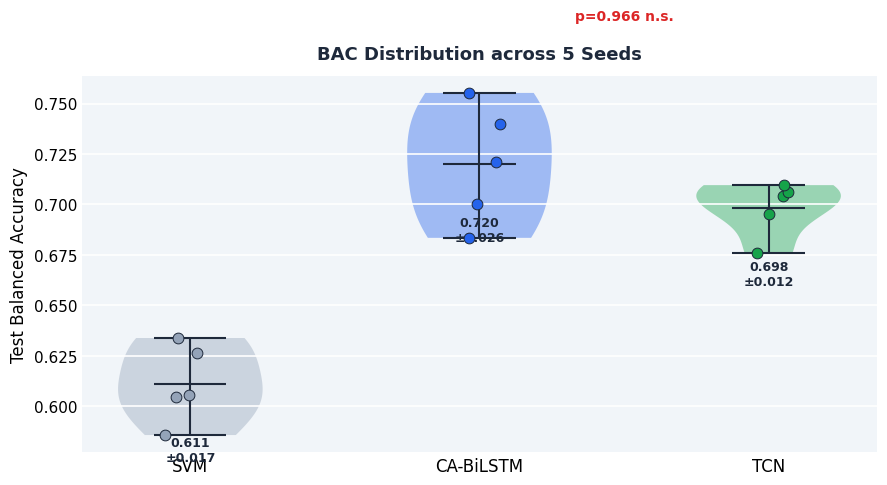

In [13]:
# ── Figure 1: BAC Distribution (violin + strip) ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_facecolor(C_LGREY)

all_data = [svm_bacs, lstm_bacs, tcn_bacs]
colors   = [C_SVM, C_LSTM, C_TCN]
positions = [1, 2, 3]
mnames   = ['SVM', 'CA-BiLSTM', 'TCN']

vp = ax.violinplot(all_data, positions=positions, widths=0.5,
                   showmeans=True, showmedians=False, showextrema=True)
for pc, c in zip(vp['bodies'], colors):
    pc.set_facecolor(c); pc.set_alpha(0.4)
for part in ['cmeans','cmins','cmaxes','cbars']:
    if part in vp: vp[part].set_color(C_SLATE); vp[part].set_linewidth(1.5)

rng_j = np.random.default_rng(7)
jitter = (rng_j.random((len(SEEDS),3))-0.5)*0.18
for i, (d, c) in enumerate(zip(all_data, colors)):
    ax.scatter(np.full(len(d), positions[i]) + jitter[:,i], d,
               color=c, s=60, zorder=4, edgecolors=C_SLATE, linewidths=0.7)
    ax.text(positions[i], d.mean()-0.026,
            f'{d.mean():.3f}\n±{d.std():.3f}',
            ha='center', va='top', fontsize=9, color=C_SLATE, fontweight='600')

ax.set_xticks(positions); ax.set_xticklabels(mnames, fontsize=12)
ax.set_ylabel('Test Balanced Accuracy', fontsize=12)
ax.set_title(f'BAC Distribution across {len(SEEDS)} Seeds', pad=12, color=C_SLATE)
ax.yaxis.grid(True, color='white', linewidth=1.2, zorder=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.tick_params(length=0)

# Significance bracket TCN vs LSTM
ymax = max(max(d) for d in all_data)
yb   = ymax + 0.03
ax.annotate('', xy=(3,yb), xytext=(2,yb),
            arrowprops=dict(arrowstyle='-', color=C_RED, lw=1.8))
lbl = f'p={p_one:.3f}' + (' *' if p_one<0.05 else ' n.s.')
ax.text(2.5, yb+0.006, lbl, ha='center', color=C_RED, fontsize=10, fontweight='600')

plt.tight_layout()
plt.savefig(os.path.join(SDIR,'fig1_bac_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


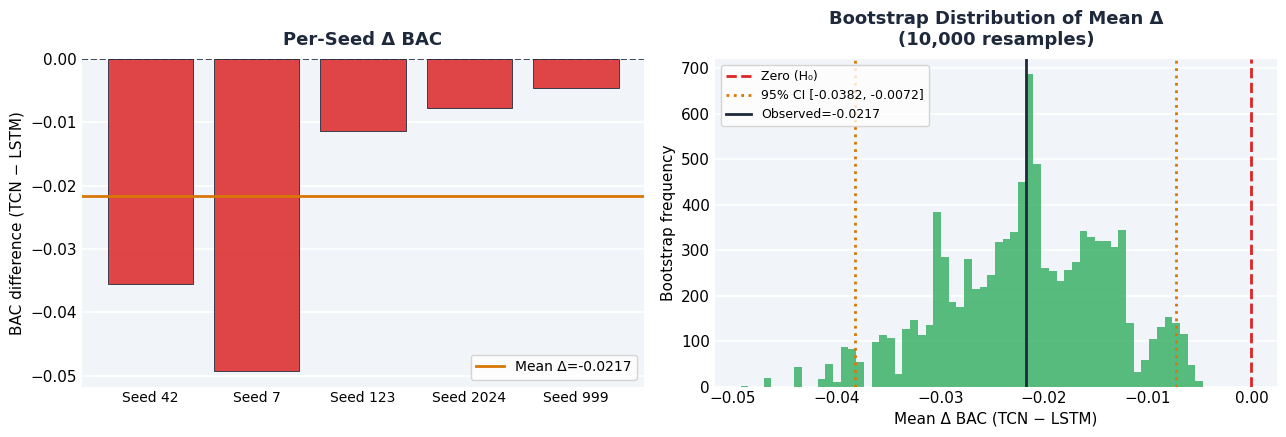

In [14]:
# ── Figure 2: Bootstrap CI ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]; ax.set_facecolor(C_LGREY)
ax.bar(range(len(diff)), diff, color=[C_TCN if d>=0 else C_RED for d in diff],
       alpha=0.85, zorder=3, edgecolor=C_SLATE, linewidth=0.7)
ax.axhline(0, color=C_SLATE, lw=1.2, ls='--', zorder=2)
ax.axhline(diff.mean(), color=C_GOLD, lw=2, ls='-', zorder=4, label=f'Mean Δ={diff.mean():+.4f}')
ax.set_xticks(range(len(SEEDS))); ax.set_xticklabels([f'Seed {s}' for s in SEEDS], fontsize=10)
ax.set_ylabel('BAC difference (TCN − LSTM)'); ax.set_title('Per-Seed Δ BAC', pad=10, color=C_SLATE)
ax.legend(fontsize=10); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)

ax = axes[1]; ax.set_facecolor(C_LGREY)
ax.hist(boot_means, bins=60, color=C_TCN, alpha=0.7, edgecolor='none', zorder=3)
ax.axvline(0,           color=C_RED,   lw=2, ls='--', zorder=4, label='Zero (H₀)')
ax.axvline(ci_low,      color=C_GOLD,  lw=2, ls=':',  zorder=4,
           label=f'95% CI [{ci_low:+.4f}, {ci_high:+.4f}]')
ax.axvline(ci_high,     color=C_GOLD,  lw=2, ls=':',  zorder=4)
ax.axvline(diff.mean(), color=C_SLATE, lw=2, ls='-',  zorder=5,
           label=f'Observed={diff.mean():+.4f}')
ax.set_xlabel('Mean Δ BAC (TCN − LSTM)'); ax.set_ylabel('Bootstrap frequency')
ax.set_title('Bootstrap Distribution of Mean Δ\n(10,000 resamples)', pad=10, color=C_SLATE)
ax.legend(fontsize=9); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)

plt.tight_layout()
plt.savefig(os.path.join(SDIR,'fig2_bootstrap_ci.png'), dpi=150, bbox_inches='tight')
plt.show()


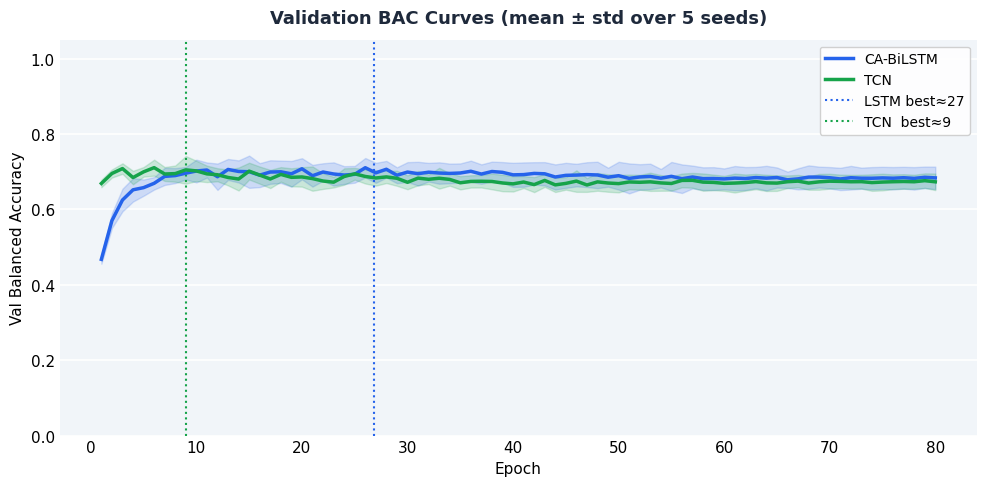

In [15]:
# ── Figure 3: Mean ± std Validation BAC Learning Curves ─────────────────
def avg_curves(res_list):
    arr = np.array([r['val_bac_hist'] for r in res_list])
    return arr.mean(0), arr.std(0)

lm, ls = avg_curves(results['lstm'])
tm, ts = avg_curves(results['tcn'])
eps    = np.arange(1, CONFIG['epochs']+1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor(C_LGREY)
for m, s, c, lbl in [(lm, ls, C_LSTM, 'CA-BiLSTM'), (tm, ts, C_TCN, 'TCN')]:
    ax.plot(eps, m, color=c, lw=2.5, label=lbl, zorder=3)
    ax.fill_between(eps, m-s, m+s, color=c, alpha=0.18, zorder=2)
ax.axvline(lstm_best_eps.mean(), color=C_LSTM, ls=':', lw=1.5,
           label=f'LSTM best≈{lstm_best_eps.mean():.0f}')
ax.axvline(tcn_best_eps.mean(),  color=C_TCN,  ls=':', lw=1.5,
           label=f'TCN  best≈{tcn_best_eps.mean():.0f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Balanced Accuracy')
ax.set_title(f'Validation BAC Curves (mean ± std over {len(SEEDS)} seeds)', pad=12, color=C_SLATE)
ax.set_ylim(0, 1.05); ax.legend(fontsize=10, framealpha=0.9); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)
plt.tight_layout()
plt.savefig(os.path.join(SDIR,'fig3_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


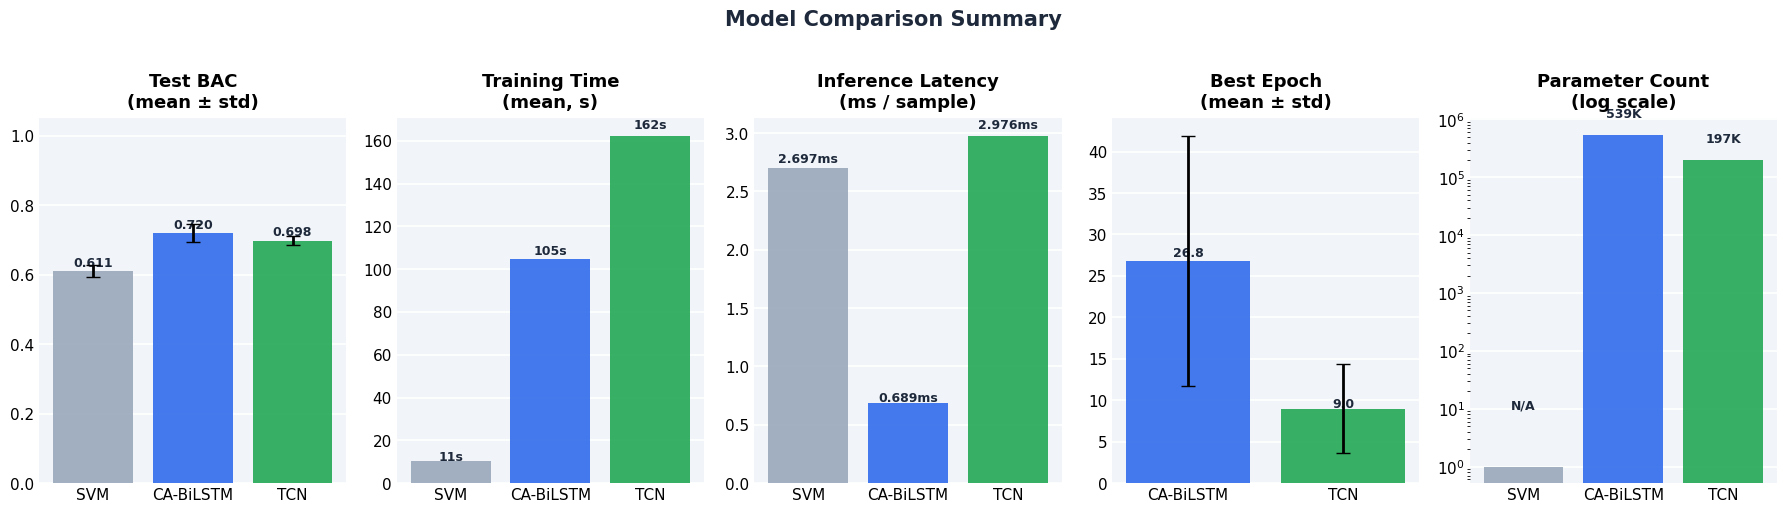

In [16]:
# ── Figure 4: Multi-metric comparison bar chart ─────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Model Comparison Summary', fontsize=15, fontweight='700', color=C_SLATE, y=1.02)

mlabels = ['SVM','CA-BiLSTM','TCN']
bcs     = [C_SVM, C_LSTM, C_TCN]

def _bar_ax(ax, labels, vals, title, fmt='{:.3f}', yerr=None, colors=None):
    ax.set_facecolor(C_LGREY)
    
    # Use provided colors or default slice
    if colors is None:
        colors = bcs[:len(labels)]
    
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, zorder=3,
                  yerr=yerr, capsize=5, error_kw={'lw':2})
    
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height()*1.02,
                fmt.format(v),
                ha='center', fontsize=9,
                fontweight='600', color=C_SLATE)
    
    ax.set_title(title, pad=8)
    ax.tick_params(length=0)
    
    for sp in ax.spines.values():
        sp.set_visible(False)
    
    ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)
    
    return bars


# ── BAC ──
_bar_ax(axes[0], mlabels,
        [svm_bacs.mean(), lstm_bacs.mean(), tcn_bacs.mean()],
        'Test BAC\n(mean ± std)', '{:.3f}',
        yerr=[svm_bacs.std(), lstm_bacs.std(), tcn_bacs.std()])
axes[0].set_ylim(0, 1.05)


# ── Training Time ──
_bar_ax(axes[1], mlabels,
        [svm_times.mean(), lstm_times.mean(), tcn_times.mean()],
        'Training Time\n(mean, s)', '{:.0f}s')


# ── Inference Latency ──
_bar_ax(axes[2], mlabels,
        [svm_inf.mean(), lstm_inf.mean(), tcn_inf.mean()],
        'Inference Latency\n(ms / sample)', '{:.3f}ms')


# ── Best Epoch (ONLY 2 MODELS) ──
_bar_ax(axes[3],
        ['CA-BiLSTM','TCN'],
        [lstm_best_eps.mean(), tcn_best_eps.mean()],
        'Best Epoch\n(mean ± std)', '{:.1f}',
        yerr=[lstm_best_eps.std(), tcn_best_eps.std()],
        colors=[C_LSTM, C_TCN])   # ✅ FIXED (no containers)


# ── Parameter Count (log scale) ──
ax = axes[4]
ax.set_facecolor(C_LGREY)

pvals = [1, LSTM_PARAMS, TCN_PARAMS]   # 1 = dummy for SVM
bars = ax.bar(mlabels, pvals, color=bcs, alpha=0.85, zorder=3)

ax.set_yscale('log')

plbls = ['N/A', f'{LSTM_PARAMS//1000}K', f'{TCN_PARAMS//1000}K']
for i, (lbl, v) in enumerate(zip(plbls, pvals)):
    ax.text(i, max(v*2, 10), lbl,
            ha='center', fontsize=9,
            fontweight='600', color=C_SLATE)

ax.set_title('Parameter Count\n(log scale)', pad=8)
ax.tick_params(length=0)

for sp in ax.spines.values():
    sp.set_visible(False)

ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)


# ── Final layout ──
plt.tight_layout()
plt.savefig(os.path.join(SDIR,'fig4_comparison_bars.png'),
            dpi=150, bbox_inches='tight')
plt.show()

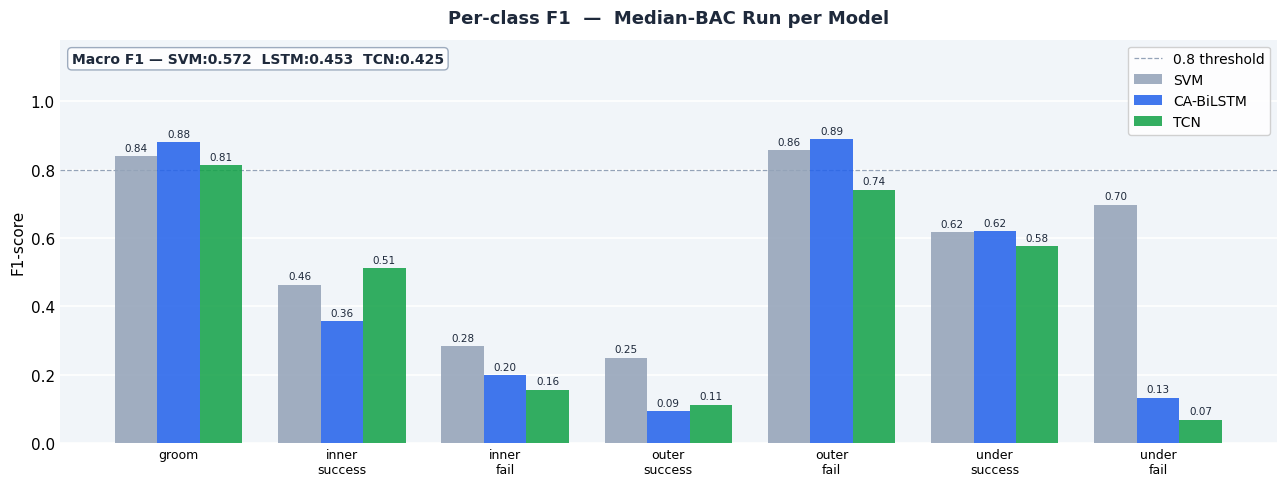

In [17]:
# ── Figure 5: Per-class F1 (median-BAC run per model) ───────────────────
def pick_median(bacs, res):
    return res[np.argsort(bacs)[len(bacs)//2]]

def per_class_f1(r):
    _, _, f1, _ = precision_recall_fscore_support(
        r['test_labels'], r['test_preds'], labels=list(range(N_CLASSES)), zero_division=0)
    return f1

f1_svm  = per_class_f1(pick_median(svm_bacs,  results['svm']))
f1_lstm = per_class_f1(pick_median(lstm_bacs, results['lstm']))
f1_tcn  = per_class_f1(pick_median(tcn_bacs,  results['tcn']))

x = np.arange(N_CLASSES); w = 0.26
fig, ax = plt.subplots(figsize=(13, 5))
ax.set_facecolor(C_LGREY)
for xi, (f1, c, lbl) in enumerate([(f1_svm,C_SVM,'SVM'),(f1_lstm,C_LSTM,'CA-BiLSTM'),(f1_tcn,C_TCN,'TCN')]):
    bars = ax.bar(x+(xi-1)*w, f1, w, label=lbl, color=c, alpha=0.87, zorder=3)
    for bar in bars:
        h = bar.get_height()
        if h > 0.04:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}',
                    ha='center', va='bottom', fontsize=7.5, color=C_SLATE)
ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES, fontsize=9)
ax.set_ylim(0,1.18); ax.set_ylabel('F1-score')
ax.set_title('Per-class F1  —  Median-BAC Run per Model', pad=12, color=C_SLATE)
ax.axhline(0.8, color=C_MGREY, ls='--', lw=0.9, zorder=2, label='0.8 threshold')
ax.legend(fontsize=10, framealpha=0.9); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color='white', lw=1.2, zorder=1)
ax.text(0.01, 0.97,
        f'Macro F1 — SVM:{f1_svm.mean():.3f}  LSTM:{f1_lstm.mean():.3f}  TCN:{f1_tcn.mean():.3f}',
        transform=ax.transAxes, fontsize=10, color=C_SLATE, va='top', fontweight='600',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C_MGREY, alpha=0.9))
plt.tight_layout()
plt.savefig(os.path.join(SDIR,'fig5_per_class_f1.png'), dpi=150, bbox_inches='tight')
plt.show()


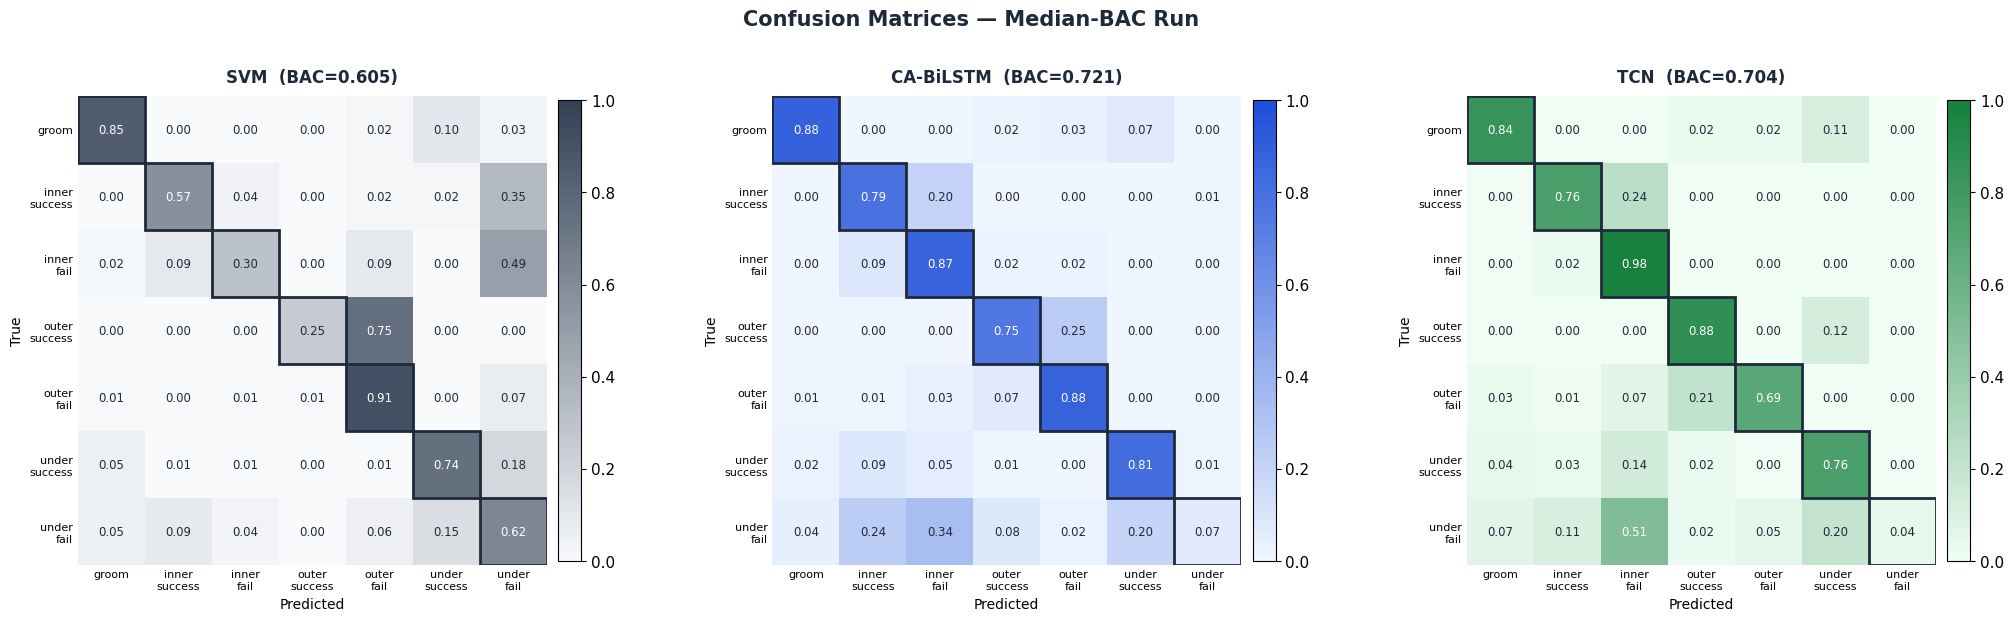

In [18]:
# ── Figure 6: Confusion Matrices (median run, row-normalised) ───────────
cmap_slate = LinearSegmentedColormap.from_list('sl', ['#F8FAFC', '#334155'])
cmap_blue  = LinearSegmentedColormap.from_list('b',  ['#EFF6FF', '#1D4ED8'])
cmap_green = LinearSegmentedColormap.from_list('g',  ['#F0FDF4', '#15803D'])

svm_med  = pick_median(svm_bacs,  results['svm'])
lstm_med = pick_median(lstm_bacs, results['lstm'])
tcn_med  = pick_median(tcn_bacs,  results['tcn'])

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Confusion Matrices — Median-BAC Run', fontsize=15,
             fontweight='700', color=C_SLATE, y=1.02)

for ax, r, cmap, title in [
    (axes[0], svm_med,  cmap_slate, 'SVM'),
    (axes[1], lstm_med, cmap_blue,  'CA-BiLSTM'),
    (axes[2], tcn_med,  cmap_green, 'TCN'),
]:
    cm   = confusion_matrix(r['test_labels'], r['test_preds'], labels=list(range(N_CLASSES)))
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    im   = ax.imshow(cm_n, cmap=cmap, vmin=0, vmax=1)
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                    fontsize=8.5, fontweight='500',
                    color='white' if cm_n[i,j]>0.5 else C_SLATE)
        ax.add_patch(mpatches.Rectangle((i-.5,i-.5),1,1, lw=2, edgecolor=C_SLATE, facecolor='none'))
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(SHORT_NAMES, fontsize=8); ax.set_yticklabels(SHORT_NAMES, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=10); ax.set_ylabel('True', fontsize=10)
    ax.set_title(f'{title}  (BAC={r["test_bac"]:.3f})', fontsize=12, pad=10, color=C_SLATE)
    ax.tick_params(length=0)
    for sp in ax.spines.values(): sp.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(SDIR,'fig6_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()


## Final Comparison Table

In [19]:
print('\n' + '='*90)
print(f'  FINAL COMPARISON TABLE  ({len(SEEDS)} seeds: {SEEDS})')
print('='*90)

cols   = ['Metric','SVM','CA-BiLSTM','TCN','TCN vs LSTM']
widths = [32, 18, 18, 18, 18]
print(''.join(c.ljust(w) for c,w in zip(cols,widths)))
print('-'*90)

def row(label, svm_v, lstm_v, tcn_v, delta=''):
    vals = [label, svm_v, lstm_v, tcn_v, delta]
    print(''.join(str(v).ljust(w) for v,w in zip(vals,widths)))

row('Test BAC (mean)',
    f'{svm_bacs.mean():.4f}', f'{lstm_bacs.mean():.4f}', f'{tcn_bacs.mean():.4f}',
    f'{diff.mean():+.4f}')
row('Test BAC (std)',
    f'{svm_bacs.std():.4f}',  f'{lstm_bacs.std():.4f}',  f'{tcn_bacs.std():.4f}')
row('Test BAC (max)',
    f'{svm_bacs.max():.4f}',  f'{lstm_bacs.max():.4f}',  f'{tcn_bacs.max():.4f}')
row('Test Accuracy (mean)',
    f'{np.mean([r["test_acc"] for r in results["svm"]]):.4f}',
    f'{np.mean([r["test_acc"] for r in results["lstm"]]):.4f}',
    f'{np.mean([r["test_acc"] for r in results["tcn"]]):.4f}')
row('Trainable Params',
    'N/A (kernel)', f'{LSTM_PARAMS:,}', f'{TCN_PARAMS:,}',
    f'{TCN_PARAMS/LSTM_PARAMS:.2f}× LSTM')
row('BAC per kParam',
    'N/A',
    f'{lstm_bacs.mean()/(LSTM_PARAMS/1000):.5f}',
    f'{tcn_bacs.mean()/(TCN_PARAMS/1000):.5f}')
row('Train Time (mean, s)',
    f'{svm_times.mean():.1f}', f'{lstm_times.mean():.1f}', f'{tcn_times.mean():.1f}')
row('Inference Latency (ms/sample)',
    f'{svm_inf.mean():.3f}', f'{lstm_inf.mean():.3f}', f'{tcn_inf.mean():.3f}')
row('Best Epoch (mean ± std)',
    'N/A',
    f'{lstm_best_eps.mean():.1f}±{lstm_best_eps.std():.1f}',
    f'{tcn_best_eps.mean():.1f}±{tcn_best_eps.std():.1f}',
    f'{tcn_best_eps.mean()-lstm_best_eps.mean():+.1f} ep')
row('Parallelisable (Conv)',     'No',   'No',   'Yes')
row('Auxiliary position task',   'No',   'No',   'Yes')
row('Receptive field (bins)',     'All',  'All',
    str((2**len(CONFIG["tcn_channels"])-1)*2+1))

print('-'*90)
print(f'Bootstrap 95% CI  mean(TCN−LSTM) : [{ci_low:+.4f}, {ci_high:+.4f}]')
print(f'Paired t-test p (one-sided, TCN>LSTM) : {p_one:.4f}'
      + ('  *significant*' if p_one<0.05 else '  (not significant)'))
print('='*90)



  FINAL COMPARISON TABLE  (5 seeds: [42, 7, 123, 2024, 999])
Metric                          SVM               CA-BiLSTM         TCN               TCN vs LSTM       
------------------------------------------------------------------------------------------
Test BAC (mean)                 0.6113            0.7200            0.6982            -0.0217           
Test BAC (std)                  0.0172            0.0260            0.0122                              
Test BAC (max)                  0.6338            0.7553            0.7096                              
Test Accuracy (mean)            0.7185            0.4871            0.4809                              
Trainable Params                N/A (kernel)      539,728           197,564           0.37× LSTM        
BAC per kParam                  N/A               0.00133           0.00353                             
Train Time (mean, s)            10.6              104.6             162.3                               
Inferen